# Modeling — xwOBAcon RF (`xwobacon`)

Production **Random Forest** contact-quality model (BIP only).

**Design:** pitch-level xwOBAcon is too noisy for greedy forward selection — this notebook fits **one master model** on the **full combined feature space**.

Logic: `src/rf_xwobacon_modeling.py`.

## 1. Target & sample

**Target:** `xwobacon` on balls in play with non-null xwOBA.

## Architecture (matches baseline LR notebooks)

| Split | Dates | Purpose |
|-------|-------|---------|
| **Train** | Mar–Jul 2025 (`game_date < 2025-08-01`) | Fit models |
| **Validation** | Aug 2025 | Not used (full feature stack; noisy target) |
| **Test** | Sep 2025 | Locked holdout — final metrics once |

**Batter signal:** season-to-date rolling metrics (`swing_pct`, `whiff_pct`, `z_swing_pct`, `o_swing_pct`, `z_whiff_pct`, `o_whiff_pct`) — no `batter_id` or `batter_te`.

**Platoon:** `same_handed`

**Pitch physics (three groups):** `pitch_movement` (`norm_hb`, `norm_ivb`) → `pitcher_delivery` (release point, extension, `p_throws_L`) → `pitch_quality` (`release_speed`, `release_spin_rate`).

**Pitch types:** all **10** competitive Statcast codes via one-hot `pitch_*` columns.

**Kitchen-sink features (whiff / xwOBAcon — all groups, no forward selection):** `pitch_type` → `pitch_quality` → `count` → `batter_rolling` → `bat_tracking` → `pitch_movement` → `pitcher_delivery` → `attack_zone` → `base_state` → `platoon`.


## 2. Process

| Step | Choice |
|------|--------|
| **Sample** | BIP with valid `xwobacon` |
| **Features** | Baseline + **all** candidate groups combined (no forward selection) |
| **Train** | Mar–Jul BIP (`train`) |
| **Test** | September BIP (`test`) — locked holdout |
| **Model** | `RandomForestRegressor(n_estimators=100, max_depth=6, min_samples_leaf=50, max_features='sqrt')` |
| **Artifact** | `models/xwobacon_rf_master.joblib` |

August validation is **not** used for feature selection — only Mar–Jul fit and Sep eval.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

NB_DIR = Path.cwd().resolve()
ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

MODELING_FILE = ROOT / "data" / "modeling_frame_2025.parquet"
if not MODELING_FILE.exists():
    raise FileNotFoundError(
        f"Run 03_feature_engineering.ipynb first — missing {MODELING_FILE}"
    )

import importlib
import src.feature_engineering as feature_engineering
import src.rf_xwobacon_modeling as rf_xwobacon_modeling

importlib.reload(feature_engineering)
importlib.reload(rf_xwobacon_modeling)

import numpy as np

from src.rf_xwobacon_modeling import (
    BASELINE_FEATURES,
    FEATURE_GROUP_ORDER,
    FEATURE_GROUPS,
    TARGET,
    TRAIN_END,
    VAL_END,
    chronological_split,
    combined_feature_columns,
    contact_only,
    feature_groups_summary,
    feature_importance_from_model,
    train_master_model,
    xwobacon_target_definition,
)

frame = pd.read_parquet(MODELING_FILE)
train, val, test = chronological_split(frame)
train_bip = contact_only(train)
test_bip = contact_only(test)

display(Markdown(xwobacon_target_definition()))
print(f"BIP — train: {len(train_bip):,} | test: {len(test_bip):,}")
print(
    f"xwOBAcon mean — train: {train_bip[TARGET].mean():.3f} | "
    f"test: {test_bip[TARGET].mean():.3f}"
)
print(f"Train: Mar–Jul (< {TRAIN_END.date()}) | Test: Sep (>= {VAL_END.date()})")


Target `xwobacon` = Statcast `estimated_woba_using_speedangle` on balls in play (hit_into_play, hit_into_play_no_out, hit_into_play_score); NaN otherwise. Training rows are **contact only** with a non-null target.

BIP — train: 81,597 | test: 18,399
xwOBAcon mean — train: 0.368 | test: 0.374
Train: Mar–Jul (< 2025-08-01) | Test: Sep (>= 2025-09-01)


## 3. Combined feature space

In [2]:
print("Baseline features:", BASELINE_FEATURES)
print("\nCandidate groups (all included in master model; includes bat_tracking):")
for name in FEATURE_GROUP_ORDER:
    print(f"  • {name}: {len(FEATURE_GROUPS[name])} columns")
    if name in ("batter_rolling", "bat_tracking", "pitch_movement", "pitcher_delivery", "pitch_quality"):
        print(f"      {FEATURE_GROUPS[name]}")

ALL_FEATURES = combined_feature_columns()
print(f"\nCombined feature count: {len(ALL_FEATURES)}")
display(feature_groups_summary())


Baseline features: ['is_in_zone', 'miss_dist_in', 'center_dist_in']

Candidate groups (all included in master model; includes bat_tracking):
  • pitch_type: 10 columns
  • pitch_quality: 2 columns
      ['release_speed', 'release_spin_rate']
  • count: 12 columns
  • batter_rolling: 6 columns
      ['swing_pct', 'whiff_pct', 'z_swing_pct', 'o_swing_pct', 'z_whiff_pct', 'o_whiff_pct']
  • bat_tracking: 3 columns
      ['bat_speed', 'attack_angle', 'squared_up_rate']
  • pitch_movement: 2 columns
      ['norm_hb', 'norm_ivb']
  • pitcher_delivery: 5 columns
      ['release_pos_x', 'release_pos_y', 'release_pos_z', 'release_extension', 'p_throws_L']
  • attack_zone: 4 columns
  • base_state: 8 columns
  • platoon: 1 columns

Combined feature count: 56


,group,n_columns
0,baseline,3
1,pitch_type,10
2,pitch_quality,2
3,count,12
4,batter_rolling,6
5,bat_tracking,3
6,pitch_movement,2
7,pitcher_delivery,5
8,attack_zone,4
9,base_state,8


## 4. Fit master model (Mar–Jul) and evaluate (September test)

Single fit on the full matrix — no greedy group selection.

In [3]:
master = train_master_model(train, test, ALL_FEATURES, name="master (full feature stack)")

print(f"Features: {len(ALL_FEATURES)}")
print(f"Train — RMSE: {master.train_rmse:.4f} | R²: {master.train_r2:.3f}")
print(f"Test  — RMSE: {master.test_rmse:.4f} | R²: {master.test_r2:.3f}")
print(f"R² gap (train − test): {master.train_r2 - master.test_r2:.3f}")


Features: 56
Train — RMSE: 0.3687 | R²: 0.037
Test  — RMSE: 0.3779 | R²: 0.029
R² gap (train − test): 0.008


## 5. Visuals

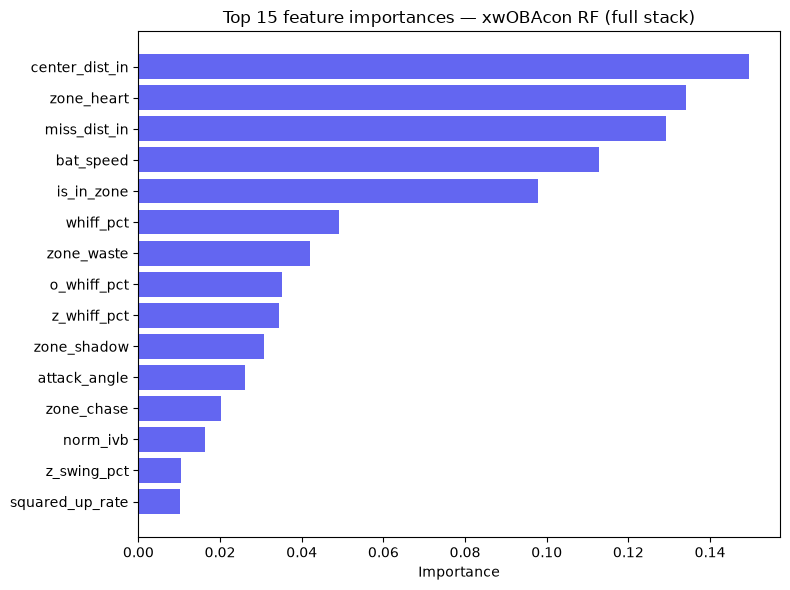

,feature,importance
0,center_dist_in,0.149646
1,zone_heart,0.134048
2,miss_dist_in,0.129144
3,bat_speed,0.112822
4,is_in_zone,0.097854
5,whiff_pct,0.049032
6,zone_waste,0.041991
7,o_whiff_pct,0.035148
8,z_whiff_pct,0.034525
9,zone_shadow,0.030772


In [4]:
top15 = feature_importance_from_model(master.model, ALL_FEATURES).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15["feature"][::-1], top15["importance"][::-1], color="#6366f1")
ax.set_title("Top 15 feature importances — xwOBAcon RF (full stack)")
ax.set_xlabel("Importance")
fig.tight_layout()
plt.show()

display(top15)


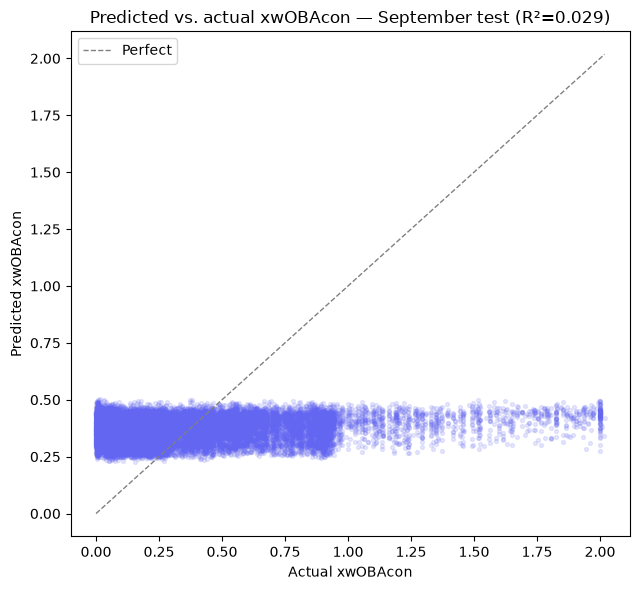

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(master.y_test, master.y_pred_test, alpha=0.15, s=8, color="#6366f1")
lims = [0, max(master.y_test.max(), master.y_pred_test.max())]
ax.plot(lims, lims, "--", color="gray", linewidth=1, label="Perfect")
ax.set_title(f"Predicted vs. actual xwOBAcon — September test (R²={master.test_r2:.3f})")
ax.set_xlabel("Actual xwOBAcon")
ax.set_ylabel("Predicted xwOBAcon")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


## 6. Calibration check — predicted bins vs. actual mean

Even when raw predicted values are compressed, an upward trend in actual xwOBAcon across predicted bins confirms the model ranks dangerous contact correctly.

September test global mean xwOBAcon: 0.374
Predicted range: 0.228 – 0.504


,bin_label,n,pred_mean,actual_mean
0,"(0.202, 0.252]",117,0.246338,0.197889
1,"(0.252, 0.302]",2631,0.283008,0.285400
2,"(0.302, 0.353]",4251,0.328572,0.329665
3,"(0.353, 0.403]",5172,0.378593,0.370926
4,"(0.403, 0.453]",5436,0.425589,0.431777
5,"(0.453, 0.504]",792,0.466026,0.552039


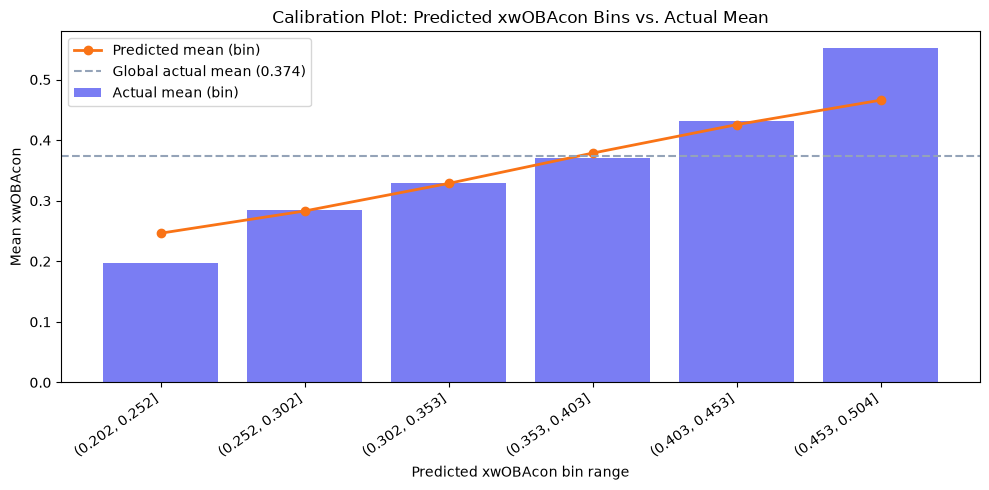

Actual mean increases monotonically across bins — strong ranking signal.


In [6]:
y_pred = master.y_pred_test
y_test = master.y_test
global_mean = float(np.mean(y_test))

N_BINS = 10
bin_edges = np.linspace(0.0, float(y_pred.max()), N_BINS + 1)
cal_df = pd.DataFrame({"y_pred": y_pred, "y_test": y_test})
cal_df["bin"] = pd.cut(cal_df["y_pred"], bins=bin_edges, include_lowest=True)

bin_summary = (
    cal_df.groupby("bin", observed=True)
    .agg(
        pred_mean=("y_pred", "mean"),
        actual_mean=("y_test", "mean"),
        n=("y_test", "size"),
    )
    .reset_index()
)
bin_summary["bin_label"] = bin_summary["bin"].astype(str)

print(f"September test global mean xwOBAcon: {global_mean:.3f}")
print(f"Predicted range: {y_pred.min():.3f} – {y_pred.max():.3f}")
display(bin_summary[["bin_label", "n", "pred_mean", "actual_mean"]])

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(bin_summary))
ax.bar(x, bin_summary["actual_mean"], color="#6366f1", alpha=0.85, label="Actual mean (bin)")
ax.plot(x, bin_summary["pred_mean"], color="#f97316", marker="o", linewidth=2, label="Predicted mean (bin)")
ax.axhline(global_mean, color="#94a3b8", linestyle="--", linewidth=1.5, label=f"Global actual mean ({global_mean:.3f})")
ax.set_xticks(x)
ax.set_xticklabels(bin_summary["bin_label"], rotation=35, ha="right")
ax.set_xlabel("Predicted xwOBAcon bin range")
ax.set_ylabel("Mean xwOBAcon")
ax.set_title("Calibration Plot: Predicted xwOBAcon Bins vs. Actual Mean")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

mono = bin_summary["actual_mean"].diff().dropna()
if (mono >= 0).all():
    print("Actual mean increases monotonically across bins — strong ranking signal.")
elif bin_summary["actual_mean"].iloc[-1] > bin_summary["actual_mean"].iloc[0]:
    print("Actual mean trends upward from lowest to highest bin — model ranks dangerous contact.")
else:
    print("Actual mean does not trend upward — review bin counts (sparse tails) or model fit.")


## 7. Save production artifact

In [7]:
import joblib

MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
ARTIFACT_PATH = MODELS_DIR / "xwobacon_rf_master.joblib"

artifact = {
    "model": master.model,
    "features": ALL_FEATURES,
    "target": TARGET,
    "train_end": str(TRAIN_END.date()),
    "val_end": str(VAL_END.date()),
    "test_rmse": master.test_rmse,
    "test_r2": master.test_r2,
    "train_r2": master.train_r2,
    "feature_selection": "combined_all_groups",
}

joblib.dump(artifact, ARTIFACT_PATH)
print(f"Saved master xwOBAcon RF -> {ARTIFACT_PATH}")
print(f"Features: {len(ALL_FEATURES)}")


Saved master xwOBAcon RF -> C:\Users\tabshire\Desktop\Portfolio\models\xwobacon_rf_master.joblib
Features: 56


## 8. Summary

Master xwOBAcon RF uses the **full combined feature stack** because pitch-level contact quality is too noisy for forward selection. The **calibration plot** (section 6) checks whether higher predicted bins correspond to higher actual xwOBAcon — ranking utility even when R² is modest. Compare September test RMSE/R² to **`08_modeling_xwobacon_lr.ipynb`**, then continue to **`10_expected_value_engine.ipynb`**.